In [2]:
# import necessary packages
import cmapPy.pandasGEXpress.GCToo as GCToo
from cmapPy.pandasGEXpress.parse import parse
import cmapPy.pandasGEXpress.subset_gctoo as sg

import pandas as pd
from scipy import stats

import matplotlib.pyplot as plt
import seaborn as sns

## Select only the 978 landmark genes and all the samples that had a high transcriptional response to drug compounds

#### *1. Select the 978 landmark gene ids to extract from .gctx file*

In [3]:
# read gene info from gene_info metadata
file_path = "/home/katie_huang_student_uml_edu/LINCS_dataset/GSE70138_Broad_LINCS_gene_info_2017-03-06.txt"
gene_info = pd.read_csv(file_path, sep="\t", dtype=str)
gene_info.head()

,pr_gene_id,pr_gene_symbol,pr_gene_title,pr_is_lm,pr_is_bing
0,780,DDR1,discoidin domain receptor tyrosine kinase 1,1,1
1,7849,PAX8,paired box 8,1,1
2,2978,GUCA1A,guanylate cyclase activator 1A,0,0
3,2049,EPHB3,EPH receptor B3,0,1
4,2101,ESRRA,estrogen related receptor alpha,0,1


In [4]:
# select the ids of only the landmark genes
lm_gene_id = gene_info["pr_gene_id"][gene_info["pr_is_lm"] == "1"]

# check that I have the 978 landmark genes
print(len(lm_gene_id)) 

978


#### *2. Filter out only the trt_cp data using GSE70138_Broad_LINCS_sig_info.txt and save into trt_cps_sig_info.txt with the command line:*
``` bash
grep trt_cp GSE70138_Broad_LINCS_sig_info.txt | cut -f-3,5-8 > trt_cps.txt
head -1 GSE70138_Broad_LINCS_sig_info.txt | cut -f-3,5-8 > column_names_sig_info.txt
cat column_names_sig_info.txt trt_cps.txt > trt_cps_sig_info.txt
rm column_names_sig_info.txt trt_cps.txt
```

## Map the drugs to the diseases

The diseases related to each drug was taken from the Broad Institute:
https://repo-hub.broadinstitute.org/repurposing#download-data

In [5]:
# import the disease information for each drug
file_path = '/home/katie_huang_student_uml_edu/LINCS_dataset/repurposing_drugs_20200324.txt'
disease_info = pd.read_csv(file_path, sep="\t", dtype=str, skiprows=9)

# set the index as the name of the compound
disease_info.set_index('pert_iname', inplace=True)
disease_info.head()

,clinical_phase,moa,target,disease_area,indication
pert_iname,,,,,
(R)-(-)-apomorphine,Launched,dopamine receptor agonist,ADRA2A|ADRA2B|ADRA2C|CALY|DRD1|DRD2|DRD3|DRD4|...,neurology/psychiatry,Parkinson's Disease
(R)-(-)-rolipram,Phase 1,phosphodiesterase inhibitor,PDE4A|PDE4B|PDE4C|PDE4D|PDE5A,NaN,NaN
(R)-baclofen,Phase 3,benzodiazepine receptor agonist,GABBR1|GABBR2,NaN,NaN
(S)-(+)-rolipram,Phase 1,phosphodiesterase inhibitor,PDE4B|PDE4D,NaN,NaN
"[sar9,met(o2)11]-substance-p",Preclinical,tachykinin antagonist,TACR1,NaN,NaN


In [6]:
# remove pert_inames where there is no indication (NaN)
disease_info = disease_info[disease_info['indication'].notna()]
disease_info.head(10)

,clinical_phase,moa,target,disease_area,indication
pert_iname,,,,,
(R)-(-)-apomorphine,Launched,dopamine receptor agonist,ADRA2A|ADRA2B|ADRA2C|CALY|DRD1|DRD2|DRD3|DRD4|...,neurology/psychiatry,Parkinson's Disease
abacavir,Launched,nucleoside reverse transcriptase inhibitor,NaN,infectious disease,human immunodeficiency virus (HIV-1)
abamectin,Launched,benzodiazepine receptor agonist,GABBR1|GABBR2,infectious disease,gastrointestinal parasites
abemaciclib,Launched,CDK inhibitor,CDK4|CDK6,oncology,breast cancer
abiraterone,Launched,androgen biosynthesis inhibitor,CYP11B1|CYP17A1,oncology,prostate cancer
abiraterone-acetate,Launched,androgen biosynthesis inhibitor,CYP17A1,oncology,prostate cancer
acalabrutinib,Launched,Bruton's tyrosine kinase (BTK) inhibitor,BTK,hematologic malignancy,mantle cell lymphoma (MCL)
acamprosate,Launched,glutamate receptor antagonist,GABRA1|GABRA2|GABRA3|GABRA4|GABRA5|GABRA6|GABR...,neurology/psychiatry,abstinence from alcohol
acarbose,Launched,glucosidase inhibitor,AMY2A|MGAM,endocrinology,diabetes mellitus


In [7]:
# obtain the pert_info data
file_path = '/home/katie_huang_student_uml_edu/LINCS_dataset/GSE70138_Broad_LINCS_pert_info.txt'
pert_info = pd.read_csv(file_path, sep="\t", dtype=str)

# set the index of the dataframe as the pert_iname
pert_info.set_index('pert_iname', inplace=True)
pert_info.head(10)

,pert_id,canonical_smiles,inchi_key,pert_type
pert_iname,,,,
10-DEBC,BRD-K70792160,CCN(CC)CCCCN1c2ccccc2Oc2ccc(Cl)cc12,GYBXAGDWMCJZJK-UHFFFAOYSA-N,trt_cp
phorbol-myristate-acetate,BRD-K68552125,CCCCCCCCCCCCCC(=O)O[C@@H]1[C@@H](C)[C@]2(O)[C@...,PHEDXBVPIONUQT-RGYGYFBISA-N,trt_cp
"16,16-dimethylprostaglandin-e2",BRD-K92301463,CCCCC(C)(C)[C@H](O)\C=C\[C@H]1[C@H](O)CC(=O)[C...,QAOBBBBDJSWHMU-WMBBNPMCSA-N,trt_cp
17-hydroxyprogesterone-caproate,BRD-A29731977,CCCCCC(=O)O[C@@]1(CCC2C3CCC4=CC(=O)CC[C@]4(C)C...,DOMWKUIIPQCAJU-JKPPDDDBSA-N,trt_cp
2-iminobiotin,BRD-K07954936,OC(=O)CCCC[C@@H]1SC[C@@H]2NC(=N)N[C@H]12,WWVANQJRLPIHNS-ZKWXMUAHSA-N,trt_cp
2-methoxyestradiol,BRD-K44408410,COc1cc2[C@H]3CC[C@]4(C)[C@@H](O)CC[C@H]4[C@@H]...,CQOQDQWUFQDJMK-SSTWWWIQSA-N,trt_cp
"2',5'-dideoxyadenosine",BRD-A20131130,CC1OC(CC1O)n1cnc2c(N)ncnc12,FFHPXOJTVQDVMO-UHFFFAOYSA-N,trt_cp
3-amino-benzamide,BRD-K08703257,NC(=O)c1cccc(N)c1,GSCPDZHWVNUUFI-UHFFFAOYSA-N,trt_cp
3-deazaadenosine,BRD-A79431551,Nc1nccc2n(cnc12)[C@@H]1O[C@H](CO)C(O)C1O,DBZQFUNLCALWDY-JXACCQRMSA-N,trt_cp


In [8]:
# select only the drugs associated with a disease
drug_to_disease = pert_info.merge(disease_info, how='inner', on='pert_iname')
drug_to_disease.head()

,pert_id,canonical_smiles,inchi_key,pert_type,clinical_phase,moa,target,disease_area,indication
pert_iname,,,,,,,,,
17-hydroxyprogesterone-caproate,BRD-A29731977,CCCCCC(=O)O[C@@]1(CCC2C3CCC4=CC(=O)CC[C@]4(C)C...,DOMWKUIIPQCAJU-JKPPDDDBSA-N,trt_cp,Launched,progesterone receptor agonist,AR|ESR1|ESR2|NR1H4|NR1I2|NR3C1|PGR,obstetrics/gynecology,spontaneous preterm birth
5-aminolevulinic-acid,BRD-K57631554,NCC(=O)CCC(O)=O,ZGXJTSGNIOSYLO-UHFFFAOYSA-N,trt_cp,Launched,oxidizing agent,ALAD,oncology|dermatology,glioma|actinic keratosis (AK)
abacavir,BRD-A95032015,Nc1nc(NC2CC2)c2ncn(C3C[C@H](CO)C=C3)c2n1,MCGSCOLBFJQGHM-HNHGDDPOSA-N,trt_cp,Launched,nucleoside reverse transcriptase inhibitor,NaN,infectious disease,human immunodeficiency virus (HIV-1)
abiraterone-acetate,BRD-K16133773,CC(=O)O[C@H]1CC[C@]2(C)[C@@H]3CC[C@@]4(C)[C@@H...,UVIQSJCZCSLXRZ-HCWFNAMGSA-N,trt_cp,Launched,androgen biosynthesis inhibitor,CYP17A1,oncology,prostate cancer
acarbose,BRD-K01621533,C[C@@H]1O[C@H](O[C@@H]2[C@H](CO)O[C@H](O[C@@H]...,XUFXOAAUWZOOIT-PCKYEMPFSA-N,trt_cp,Launched,glucosidase inhibitor,AMY2A|MGAM,endocrinology,diabetes mellitus


In [9]:
# calculate the total number of drugs associated with a disease
len(drug_to_disease)

884

In [10]:
# sort the drugs by their disease area and disease indication
drug_to_disease = drug_to_disease.sort_values(by=['disease_area', 'indication'])
drug_to_disease.head()

,pert_id,canonical_smiles,inchi_key,pert_type,clinical_phase,moa,target,disease_area,indication
pert_iname,,,,,,,,,
acrivastine,BRD-K50163129,Cc1ccc(cc1)C(=C/CN1CCCC1)\c1cccc(\C=C\C(O)=O)n1,PWACSDKDOHSSQD-IUTFFREVSA-N,trt_cp,Launched,histamine receptor antagonist,HRH1,allergy,allergic rhinitis
beclomethasone-dipropionate,BRD-A11319535,CCC(=O)OCC(=O)C1(OC(=O)CC)C(C)CC2C3CCC4=CC(=O)...,KUVIULQEHSCUHY-UHFFFAOYSA-N,trt_cp,Launched,glucocorticoid receptor agonist,GPR97|NR3C1,allergy,allergic rhinitis
ciclesonide,BRD-K35245662,CC(C)C(=O)OCC(=O)[C@@]12O[C@@H](O[C@@H]1C[C@H]...,LUKZNWIVRBCLON-GXOBDPJESA-N,trt_cp,Launched,glucocorticoid receptor agonist,NR3C1|SERPINA6,allergy,allergic rhinitis
clemizole,BRD-K04704168,Clc1ccc(Cn2c(CN3CCCC3)nc3ccccc23)cc1,CJXAEXPPLWQRFR-UHFFFAOYSA-N,trt_cp,Launched,HCV inhibitor,NaN,allergy,allergic rhinitis
diphenylpyraline,BRD-K22936972,CN1CCC(CC1)OC(c1ccccc1)c1ccccc1,OWQUZNMMYNAXSL-UHFFFAOYSA-N,trt_cp,Launched,dopamine reuptake inhibitor,HRH1|SLC6A3,allergy,allergic rhinitis


## Select the gene signatures ids of compounds of interest

#### *1. Select gene signature info and TAS scores of samples treated for one cell line*

In [12]:
## select the gene sig
def select_samples (cell_line, tas_threshold):
    ### 1. select the gene signatures of samples that were treated with cell line of interest
    # read the gene signature info
    file_path = "/home/katie_huang_student_uml_edu/LINCS_dataset/trt_cps_sig_info.txt"
    sig_info = pd.read_csv(file_path, sep="\t", dtype=str)
    sig_info.set_index("sig_id", inplace=True)
    ###
    
    # select only the gene signature ids for cell line
    cell_line_sig_info = sig_info[sig_info['cell_id'] == cell_line]
    
    ### 2. Of the samples treated with one cell line, select those that were above TAS threshold
    # read the TAS scores of the gene signatures
    file_path = "LINCS_dataset/all_data/GSE70138_Broad_LINCS_sig_metrics_2017-03-06.txt"
    tas_trt_cps = pd.read_csv(file_path, sep="\t", index_col=0)
    tas_trt_cps.set_index('sig_id', inplace=True)

    # get the tas scores of samples treated with cell line
    cell_line_tas = tas_trt_cps.loc[cell_line_sig_info.index, 'tas']
    
    # add the TAS scores to the sig_info for cell line
    cell_line_trt_cps = pd.concat([cell_line_sig_info, cell_line_tas], axis=1)
    
    # sort the TAS scores in descending order
    top_trt_cps = cell_line_trt_cps.sort_values(by='tas', ascending=False)
    top_trt_cps['tas'] = top_trt_cps['tas'].astype(float)

    # select only the ones above a TAS threshold
    high_tas_trt_cps = top_trt_cps[top_trt_cps['tas'] > tas_threshold]
    ###
    
    ### 3. For each unique compound, select only the samples with the highest tas score
    # create a list to store the sig ids of all the samples with that highest tas scores
    highest_tas_sig_ids = []

    # group the data by the name of the compound
    by_cps = high_tas_trt_cps.groupby("pert_iname")

    # store the compound names and their sig ids in a dictionary
    cp2samples = by_cps.groups

    # look at each compound names and the sig ids for that compound
    for cp_name, sig_ids in cp2samples.items():
        # obtain the dataframe with that data
        data = high_tas_trt_cps.loc[sig_ids]

        # sort the data by highest tas
        tas_sorted = data.sort_values('tas', ascending=False)

        # obtain the data for the sample with the highest tas scores
        highest_tas = tas_sorted.iloc[0]

        # add the sig id to the running list
        highest_tas_sig_ids.append(highest_tas.name)

    # create a dataframe containing the tas score for each unique compound whose TAS is above threshold
    samples2compare = high_tas_trt_cps.loc[highest_tas_sig_ids]
    ###
    
    return samples2compare

In [13]:
# check that this works for MCF7 cell line
samples2compare = select_samples('MCF7', 0.6)
samples2compare.head(10)

,pert_id,pert_iname,cell_id,pert_idose,pert_itime,distil_id,tas
sig_id,,,,,,,
REP.A022_MCF7_24H:I01,BRD-K71281111,SNX-2112,MCF7,10.0 um,24 h,REP.A022_MCF7_24H_X1_B23:I01|REP.A022_MCF7_24H...,0.722739
REP.A008_MCF7_24H:A09,BRD-A68009927,daunorubicin,MCF7,1.11 um,24 h,REP.A008_MCF7_24H_X1_B24:A09|REP.A008_MCF7_24H...,0.773276
REP.A011_MCF7_24H:J05,BRD-K06335600,tizanidine,MCF7,0.12 um,24 h,REP.A011_MCF7_24H_X1_B24:J05|REP.A011_MCF7_24H...,0.629051
REP.A025_MCF7_24H:P03,BRD-K79131256,albendazole,MCF7,1.11 um,24 h,REP.A025_MCF7_24H_X1_B23:P03|REP.A025_MCF7_24H...,0.654995
LJP006_MCF7_24H:H14,BRD-K43389698,BMS-387032,MCF7,3.33 um,24 h,LJP006_MCF7_24H_X1_B17:H14|LJP006_MCF7_24H_X2_...,0.751182
REP.A021_MCF7_24H:J09,BRD-K83837640,JNJ-26481585,MCF7,1.11 um,24 h,REP.A021_MCF7_24H_X1_B23:J09|REP.A021_MCF7_24H...,0.781182
REP.A018_MCF7_24H:J20,BRD-K64925568,AMG-232,MCF7,3.33 um,24 h,REP.A018_MCF7_24H_X1_B24:J20|REP.A018_MCF7_24H...,0.768454
REP.A015_MCF7_24H:O10,BRD-K61195623,combretastatin-A-4,MCF7,0.37 um,24 h,REP.A015_MCF7_24H_X1_B23:O10|REP.A015_MCF7_24H...,0.654698
LJP008_MCF7_24H:A03,BRD-K81418486,vorinostat,MCF7,10.0 um,24 h,LJP008_MCF7_24H_X1_B20:A03|LJP008_MCF7_24H_X2_...,0.707743


## Map drugs to be compared to their indications

In [14]:
def drug_to_indication(samples2compare):
    # of the samples to compare, select those that have a disease associated with it
    test_samples = samples2compare[samples2compare['pert_iname'].isin(drug_to_disease.index)]

    # obtain the unique compound ids with associated diseases
    unique_cp_ids = test_samples['pert_id'].unique()

    # list the indications of these compounds
    drug2indications = drug_to_disease[['pert_id', 'indication']][drug_to_disease['pert_id'].isin(unique_cp_ids)]
    
    return drug2indications

In [15]:
# check that function works
drug2indications = drug_to_indication(samples2compare)
drug2indications

,pert_id,indication
pert_iname,,
digoxin,BRD-A94756469,congestive heart failure|atrial fibrillation (AF)
lacidipine,BRD-K43586850,hypertension
olmesartan-medoxomil,BRD-K78485176,hypertension
ingenol-mebutate,BRD-K93779381,actinic keratosis (AK)
metronidazole,BRD-K52020312,rosacea
altrenogest,BRD-K14619660,estrus
lomitapide,BRD-K92213669,hypercholesterolemia
amsacrine,BRD-K68346641,acute lymphoblastic leukemia (ALL)
midostaurin,BRD-K13646352,acute myeloid leukemia (AML)


## Create pairs of drug ids to compare grouped by whether share (are similar drugs)

In [16]:
def generate_pairs(samples2compare, drugs2indications):
    # create an empty dictionary
    pairs2compare = {
        'similar drugs': [],
        'different drugs': []
    }

    # set the pert_id as the index
    id2indications = drug2indications.set_index('pert_id')

    # obtain all the ids of all the compounds
    all_cps = id2indications.index

    # look through the indices of the list of unique compounds up until the 2nd last index
    for idx, pert_id in enumerate(all_cps):
        # store all the indications of this compound
        indications_str = id2indications.loc[pert_id, 'indication']
        # store all the indications for this compound as set
        indications_set = set(indications_str.split('|'))
        # create a subset of the dataframe containing the remaining compounds
        other_ids = id2indications.iloc[idx+1:]
        # look through each of the remaining compounds
        for i, cp in other_ids.iterrows():
            # store the indications of each compound as a string
            other_cp_indications_str = cp['indication']
            # store the indications of each compound as a set
            other_cp_indications_set = set(other_cp_indications_str.split('|'))
            # determine the same indications across both compounds
            common_indications = indications_set.intersection(other_cp_indications_set)
            # add the pert_ids of the two drugs to the a list 
            cps_pair = [pert_id, i]

            # check if there are samples that have been treated with this compound
            cp_ids_in_data = samples2compare['pert_id'].isin(cps_pair)
            # get the data associated with these compounds
            cp_data = samples2compare[cp_ids_in_data]

            # if they share indications,
            if common_indications:
                # add this data to the list of similar drugs in the dictionary
                pairs2compare['similar drugs'].append(cp_data)
            # otherwise, they are different drugs
            else:
                # add this data to the list of different drugs in the dictionary
                pairs2compare['different drugs'].append(cp_data)
                
    return pairs2compare

In [17]:
# check that you have unique pairs of compounds to compare to each other
pairs2compare = generate_pairs(samples2compare, drug2indications)
pairs2compare['similar drugs'][0]

,pert_id,pert_iname,cell_id,pert_idose,pert_itime,distil_id,tas
sig_id,,,,,,,
REP.A007_MCF7_24H:B24,BRD-K43586850,lacidipine,MCF7,0.04 um,24 h,REP.A007_MCF7_24H_X1_B22:B24|REP.A007_MCF7_24H...,0.666125
REP.A024_MCF7_24H:M12,BRD-K78485176,olmesartan-medoxomil,MCF7,0.04 um,24 h,REP.A024_MCF7_24H_X1_B23:M12|REP.A024_MCF7_24H...,0.645101


## Select gene signatures of each pair

In [18]:
# read the LINCS Level 5 dataset
file_path = "/home/katie_huang_student_uml_edu/LINCS_dataset/LINCS_dataset.gctx"

# select only the landmark gene of drug compounds of interest
gene_sigs = parse(file_path, rid=lm_gene_id, cid=samples2compare.index)

In [19]:
## creating a function to create a dataframe containing the gene signatures of the pert_ids of interest
def select_pairs_gene_sigs(gene_sigs, pairs2compare):
    # create an empty dictionary to store the gene signatures of each pair
    pairs_sig_info = {
        'similar drugs': [],
        'different drugs': []
    }

    # look at each group drugs (similar vs different)
    for group in pairs2compare:
        # get all the pairs in group
        pairs_in_group = pairs2compare[group]
        # look at each pair of compounds in each group
        for pair_of_cps in pairs_in_group:
            # create a new GCTOO object with all the metadata for pair 
            sig_info = GCToo.GCToo(data_df=gene_sigs.data_df[pair_of_cps.index].copy(), 
                            row_metadata_df=gene_sigs.row_metadata_df.copy(), 
                            col_metadata_df=pair_of_cps.copy(), 
                            make_multiindex=True)
            # add this sig info to the correct group of the new dictionary
            pairs_sig_info[group].append(sig_info)

    return pairs_sig_info

In [20]:
# separate the gene signatures into pairs that will be compared
pairs_sig_info = select_pairs_gene_sigs(gene_sigs, pairs2compare)

# show the dataframe for one pair of drugs
pairs_sig_info['similar drugs'][0].multi_index_df.head()

pert_id,BRD-K43586850,BRD-K78485176
pert_iname,lacidipine,olmesartan-medoxomil
cell_id,MCF7,MCF7
pert_idose,0.04 um,0.04 um
pert_itime,24 h,24 h
distil_id,REP.A007_MCF7_24H_X1_B22:B24|REP.A007_MCF7_24H_X2_B22:B24|REP.A007_MCF7_24H_X3.A2_B23:B24,REP.A024_MCF7_24H_X1_B23:M12|REP.A024_MCF7_24H_X2_B23:M12|REP.A024_MCF7_24H_X3_B23:M12
tas,0.666125,0.645101
cid,REP.A007_MCF7_24H:B24,REP.A024_MCF7_24H:M12
rid,,
0,-1.458264,-1.203949
1,0.301619,-0.305805


## Perform Spearman correlations for all pairs of drugs

In [21]:
# function to create a scatter plot for each drug dosage comparing 2 drug compounds
def spearman_correlation(pair_of_sigs):
    # make a scatterplot 
    #sns.scatterplot(
        #x = pair_of_sigs.data_df.iloc[:, 0],
        #y = pair_of_sigs.data_df.iloc[:, 1]
    #)
    # label x-axis of the scatterplot with the compound name
    #plt.xlabel(pair_of_sigs.col_metadata_df.iloc[0].pert_iname)
    # label y-axis of the scatterplot with the compound name
    #plt.ylabel(pair_of_sigs.col_metadata_df.iloc[1].pert_iname)
    # label title with dose being compared at
    #plt.title(pair_of_sigs.col_metadata_df.iloc[0].pert_idose)
    #plt.show()

    # perform a spearman correlation
    spearman_corr, p_value = stats.spearmanr(pair_of_sigs.data_df.iloc[:, 0], pair_of_sigs.data_df.iloc [:,1])
    #print('Spearman Correlation:', spearman_corr, 'p value:', p_value)
    return spearman_corr, p_value

#### *1. Compare all pairs of drugs that share the same indication (are similar)*

In [22]:
def compare_drugs(pairs_sig_info):
    # create a dictionary to store the spearman correlations and their respective p values
    spearman_corrs = {
        'spearman correlation': [],
        'p value': [],
        'share an indication': []
    }
    
    ### 1. compare pairs of drugs that share an indication
    # store all the pairs of drugs that share an indication in a list
    similar_pairs = pairs_sig_info['similar drugs']

    # for each pair of drugs that share an indication,
    for pair in similar_pairs:
        # make a scatter plot and perform a spearman correlation and store the correlation and p values
        corr, p = spearman_correlation(pair)

        # add the correlation to the running list of all spearman correlations
        spearman_corrs['spearman correlation'].append(corr)

        # add the p value to the running list of all p values
        spearman_corrs['p value'].append(p)

        # indicate they share an indication
        spearman_corrs['share an indication'].append('share an indication')
    ###
        
    ### 2. compare pairs of drugs that do not share an indication
    # store all the pairs of drugs that share an indication in a list
    diff_pairs = pairs_sig_info['different drugs']

    # for each pair of drugs that share an indication,
    for pair in diff_pairs:
        # make a scatter plot and perform a spearman correlation and store the correlation and p values
        corr, p = spearman_correlation(pair)

        # add the correlation to the running list of all spearman correlations
        spearman_corrs['spearman correlation'].append(corr)

        # add the p value to the running list of all p values
        spearman_corrs['p value'].append(p)

        # indicate that the two drugs do not share an indication
        spearman_corrs['share an indication'].append('do not share an indication')
    ###
    
    return spearman_corrs

In [23]:
# compare the pairs of drugs
spearman_corrs = compare_drugs(pairs_sig_info)

# convert the dictionary into a dataframe
spearman_corrs_df = pd.DataFrame(spearman_corrs)
spearman_corrs_df.head(20)

,p value,share an indication,spearman correlation
0,4.533875e-13,share an indication,0.228683
1,2.476888e-48,share an indication,0.443274
2,8.072025e-37,share an indication,0.389688
3,1.770784e-59,share an indication,0.487350
4,3.639375e-33,share an indication,0.370399
5,6.879097e-01,share an indication,0.012861
6,1.310416e-28,share an indication,0.344347
7,2.400065e-01,share an indication,0.037606
8,1.158792e-38,share an indication,0.398949
9,9.617408e-11,share an indication,0.205038


#### *2. Summarize these spearman correlations with a violin plot*

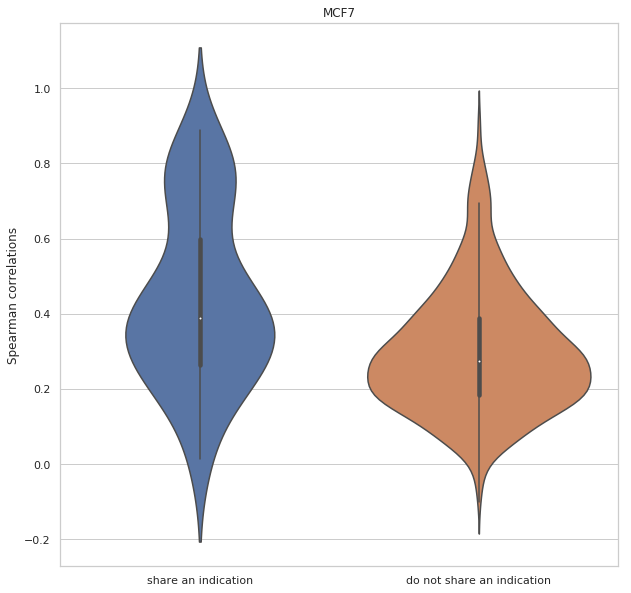

In [24]:
# create a new figure for the histograms with specified sizes
plt.figure(figsize=(10,10))

# set a grid on the histograms
sns.set(style='whitegrid')

# create a histogram of all spearman correlations for pairs of similar drugs
sns.violinplot(data=spearman_corrs, x='share an indication', y='spearman correlation', inner='box', common_norm=False)

# Customize the plot
plt.title('MCF7')
plt.ylabel("Spearman correlations")

# Show the plot
plt.show()

#### *3. Perform a ranked sum test comparing the spearman correlations of similar and different drugs*

In [25]:
### perform a Wilcoxon rank-sum test (Mann-Whitney test)
# group dataframe by whether they share an indication
grouped = spearman_corrs_df.groupby('share an indication')['spearman correlation']

# perform a ranked sum test comparing the pairs of drugs that share an indication to pairs that do not
statistic, p_value = stats.ranksums(grouped.groups['share an indication'], grouped.groups['do not share an indication'])
p_value

2.485938436573106e-27

## Run analysis for a range of TAS thresholds

#### *a. MCF7 cell line*

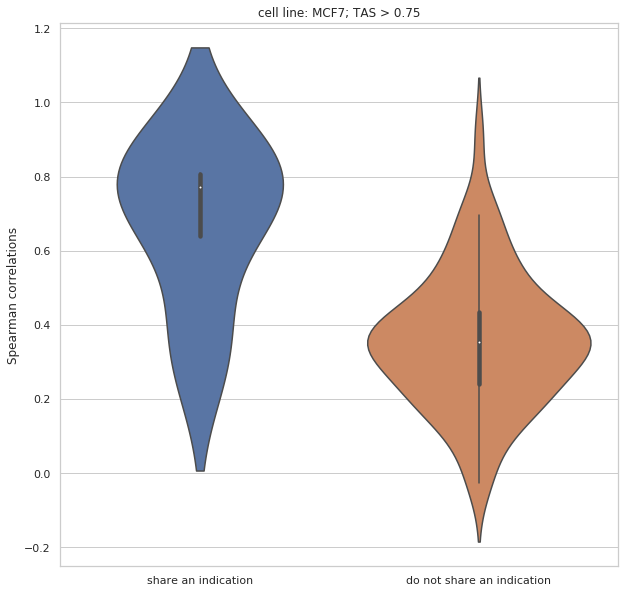

('TAS threshold', 0.75, 'p value:', 0.0008611954331049226)


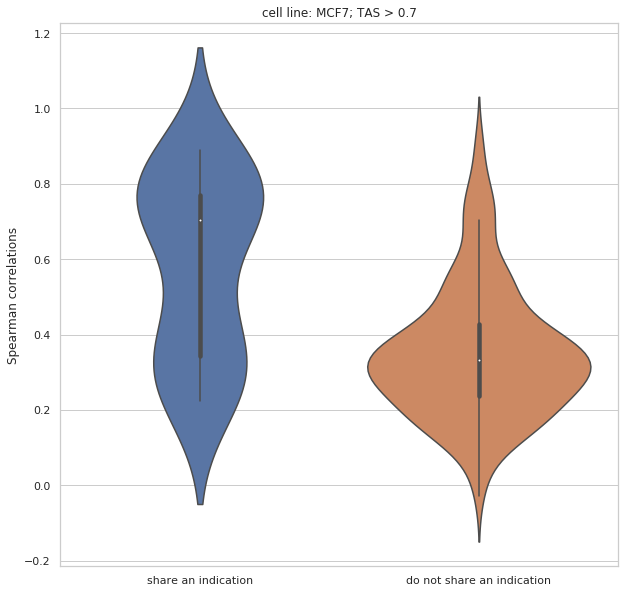

('TAS threshold', 0.7, 'p value:', 8.489777387442815e-12)


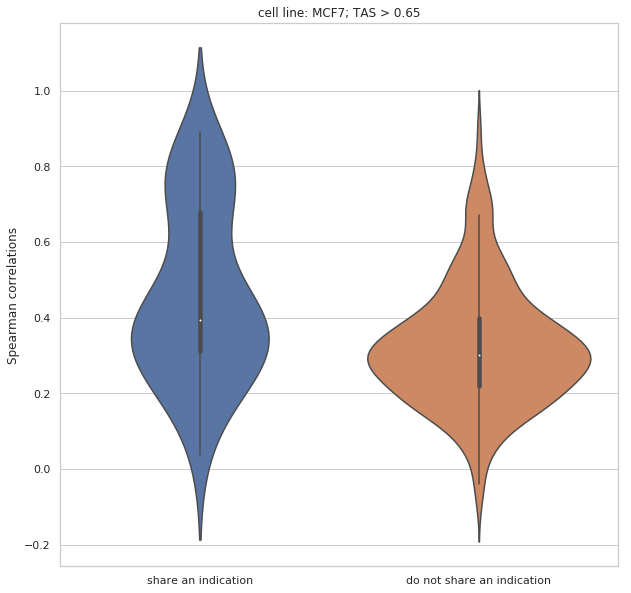

('TAS threshold', 0.65, 'p value:', 1.3725998232589532e-22)


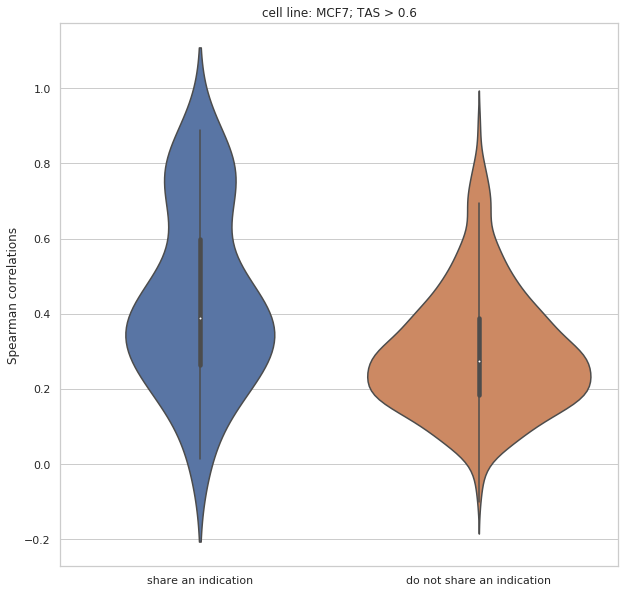

('TAS threshold', 0.6, 'p value:', 2.485938436573106e-27)


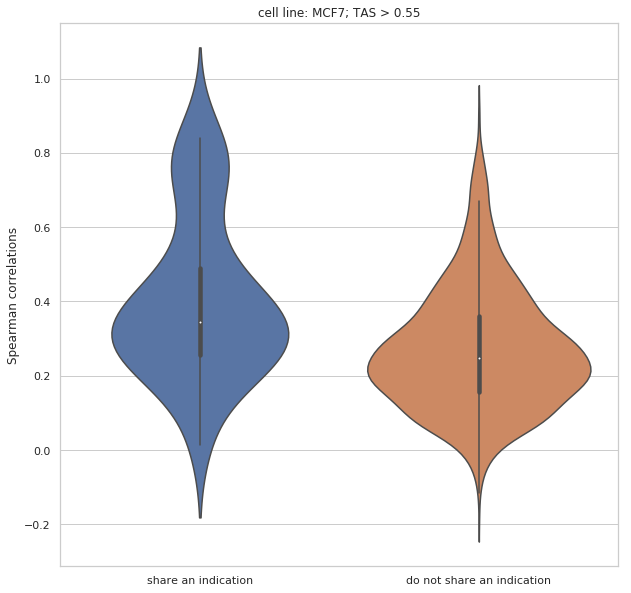

('TAS threshold', 0.55, 'p value:', 4.4221043664754644e-36)


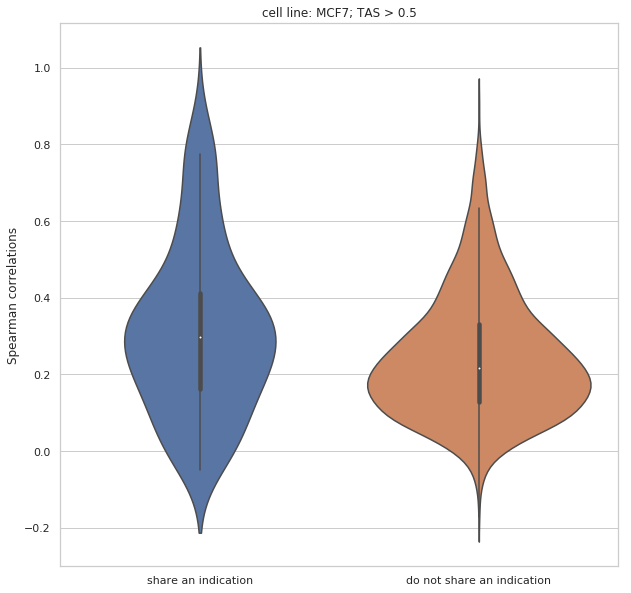

('TAS threshold', 0.5, 'p value:', 7.191022699372452e-87)


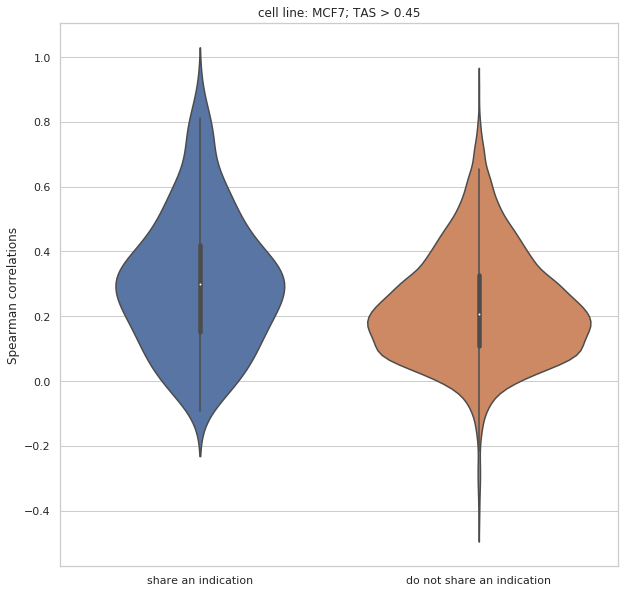

('TAS threshold', 0.45, 'p value:', 4.778656517051266e-139)


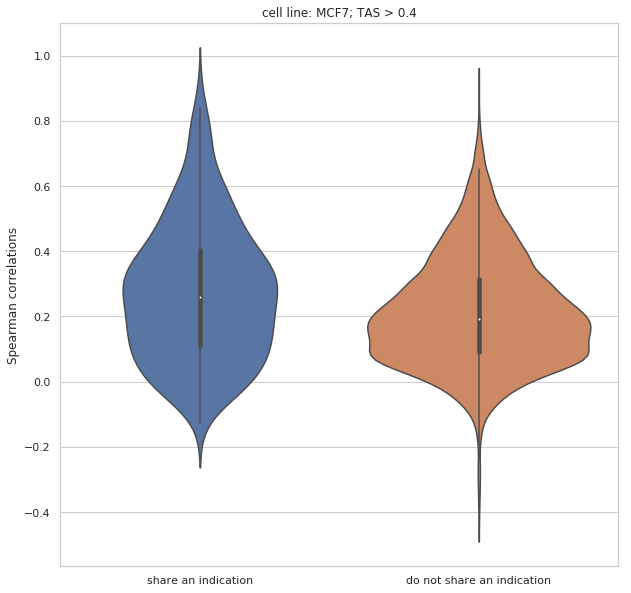

('TAS threshold', 0.4, 'p value:', 5.658247354287532e-180)


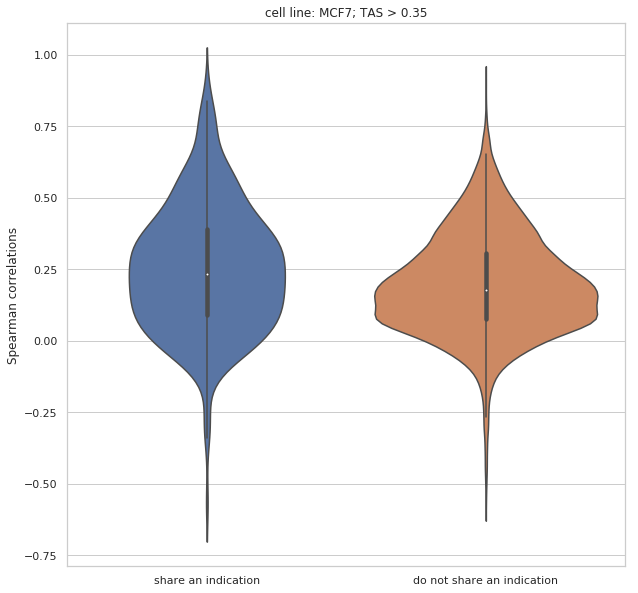

('TAS threshold', 0.35, 'p value:', 1.3269622863864595e-223)


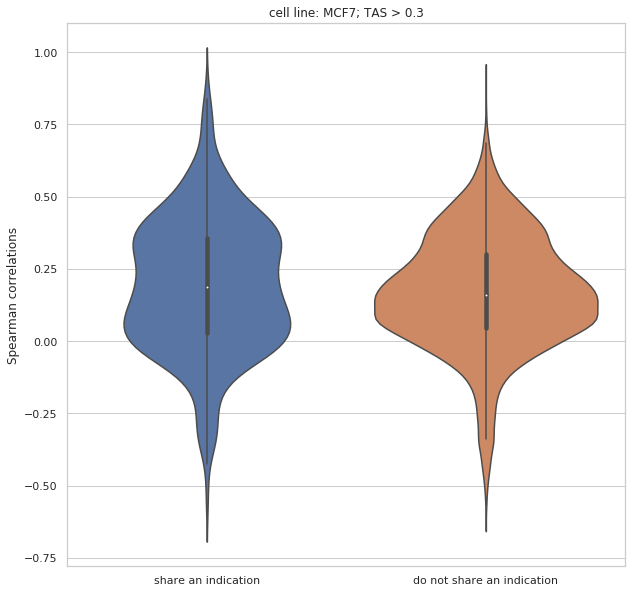

('TAS threshold', 0.3, 'p value:', 0.0)


In [35]:
# create an empty dictionary to store the spearman_correlations for each the tas_threshold
MCF7_tas_threshold_spearman_corrs = {}

# create an empty dictionary to store the results from the rank-sum test for each tas threshold
tas_threshold_rank_sum = {
    'TAS threshold': [],
    'rank sum p-value': []
}

# create a list of all TAS thresholds you want to be compared
tas_thresholds = [0.75, 0.7, 0.65, 0.6, 0.55, 0.5, 0.45, 0.4, 0.35, 0.3]

# for each TAS threshold,
for tas in tas_thresholds:
    ### 1. select the samples for that cell line above that TAS threshold
    samples2compare = select_samples('MCF7', tas)
    ###
    
    ### 2. map these samples to their indications
    drug2indications = drug_to_indication(samples2compare)
    ###
    
    ### 3. create pairs of drugs to compare
    pairs2compare = generate_pairs(samples2compare, drug2indications)
    ###
    
    ### 4. select the gene signatures of all samples to be compared
    # read the LINCS Level 5 dataset
    file_path = "/home/katie_huang_student_uml_edu/LINCS_dataset/LINCS_dataset.gctx"

    # select only the landmark gene of drug compounds of interest
    gene_sigs = parse(file_path, rid=lm_gene_id, cid=samples2compare.index)
    ###
    
    ### 5. select the gene signatures for each pair
    pairs_sig_info = select_pairs_gene_sigs(gene_sigs, pairs2compare)
    ###
    
    ### 6. compare the pairs of drugs
    spearman_corrs = compare_drugs(pairs_sig_info)
    ###

    ### 7. make a violin plot to summarize the spearman correlations
    # convert the dictionary into a dataframe
    spearman_corrs_df = pd.DataFrame(spearman_corrs)
    
    # add the spearman correlations to running list
    MCF7_tas_threshold_spearman_corrs[tas] = spearman_corrs_df
    
    # create a new figure for the histograms with specified sizes
    plt.figure(figsize=(10,10))

    # set a grid on the histograms
    sns.set(style='whitegrid')

    # create a histogram of all spearman correlations for pairs of similar drugs
    sns.violinplot(data=spearman_corrs, x='share an indication', y='spearman correlation', inner='box', common_norm=False)

    # Customize the plot
    plt.title('cell line: MCF7; TAS > ' + str(tas))
    plt.ylabel("Spearman correlations")

    # Show the plot
    plt.show()
    ###
    
    ### 8. perform a Wilcoxon rank-sum test (Mann-Whitney test)
    # group dataframe by whether they share an indication
    grouped = spearman_corrs_df.groupby('share an indication')['spearman correlation']

    # perform a ranked sum test comparing the pairs of drugs that share an indication to pairs that do not
    statistic, p_value = stats.ranksums(grouped.groups['share an indication'], grouped.groups['do not share an indication'])
    print('TAS threshold', tas,'p value:', p_value)
    
    # save the results from the test
    tas_threshold_rank_sum['TAS threshold'].append(tas)
    tas_threshold_rank_sum['rank sum p-value'].append(p_value)
    ###

In [36]:
# show the tas thresholds dataframes available
MCF7_tas_threshold_spearman_corrs.keys()

[0.75, 0.5, 0.3, 0.4, 0.55, 0.45, 0.6, 0.65, 0.35, 0.7]

In [37]:
# convert tas_threshold_rank_sum dictionary into a dataframe
MCF7_rank_sums = pd.DataFrame(tas_threshold_rank_sum)
MCF7_rank_sums

,TAS threshold,rank sum p-value
0,0.75,8.611954e-04
1,0.70,8.489777e-12
2,0.65,1.372600e-22
3,0.60,2.485938e-27
4,0.55,4.422104e-36
5,0.50,7.191023e-87
6,0.45,4.778657e-139
7,0.40,5.658247e-180
8,0.35,1.326962e-223
9,0.30,0.000000e+00


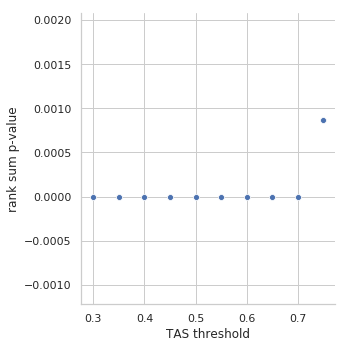

In [38]:
# create a scatter plot comparing the p-values for each tas threshold
sns.relplot(data = MCF7_rank_sums, 
            x = 'TAS threshold',
            y = 'rank sum p-value'
)

#### *b. A375 cell line*

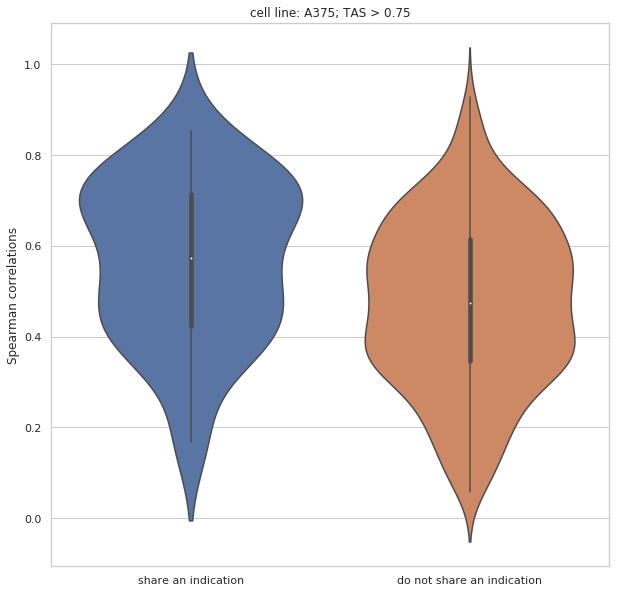

('TAS threshold', 0.75, 'p value:', 7.334669366811423e-23)


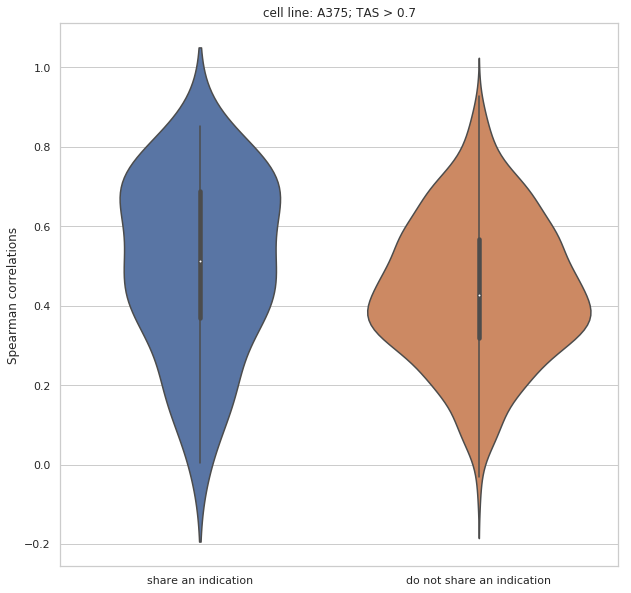

('TAS threshold', 0.7, 'p value:', 3.3596805729356885e-31)


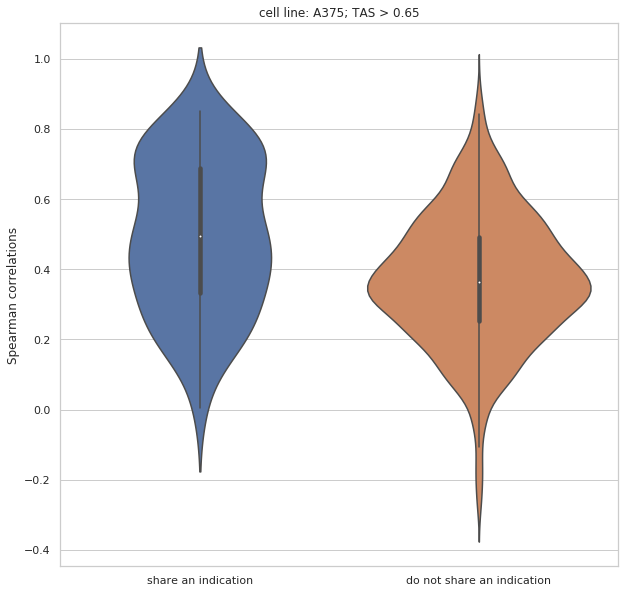

('TAS threshold', 0.65, 'p value:', 1.107945915490003e-48)


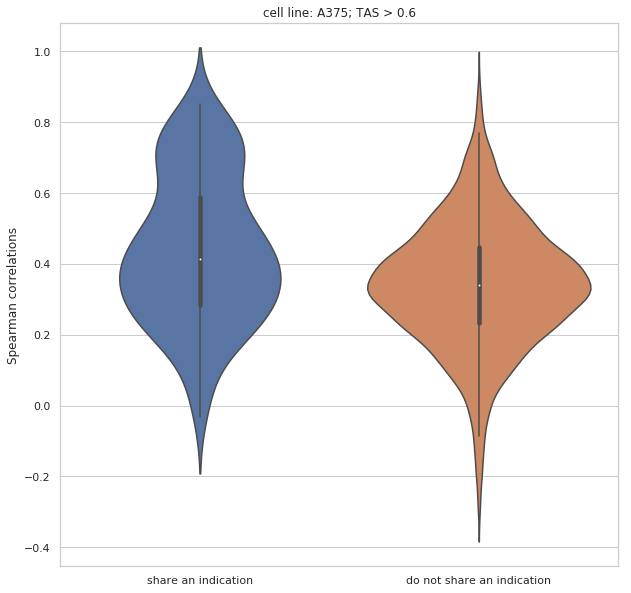

('TAS threshold', 0.6, 'p value:', 3.367611255831476e-77)


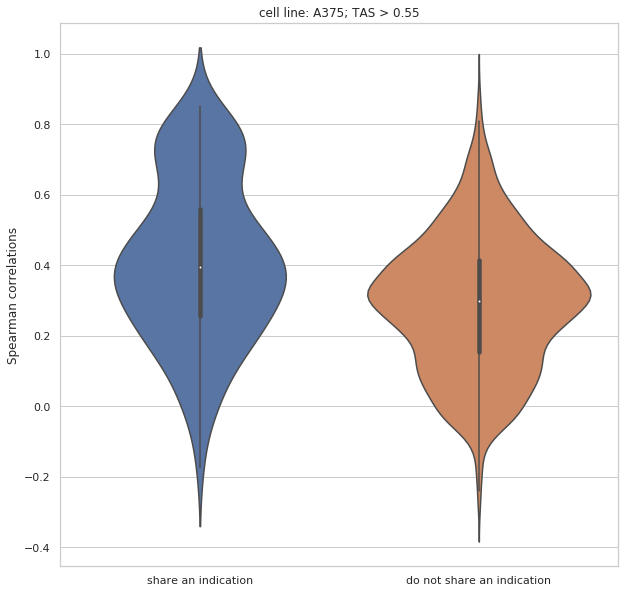

('TAS threshold', 0.55, 'p value:', 2.797174678275401e-100)


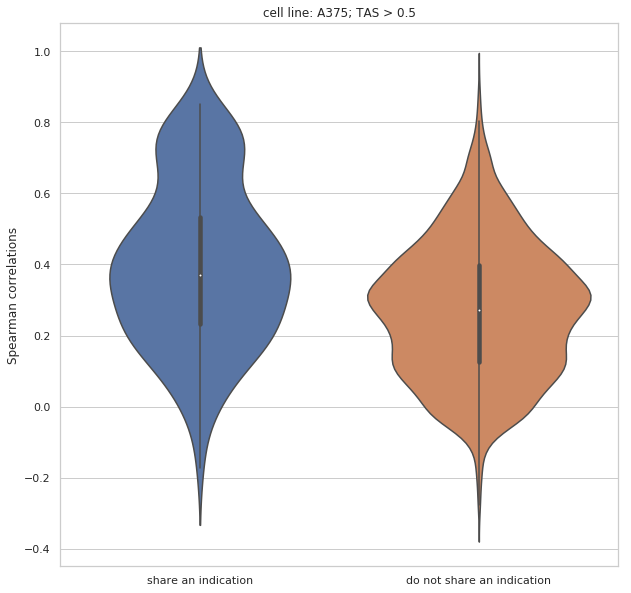

('TAS threshold', 0.5, 'p value:', 1.3927739895221583e-116)


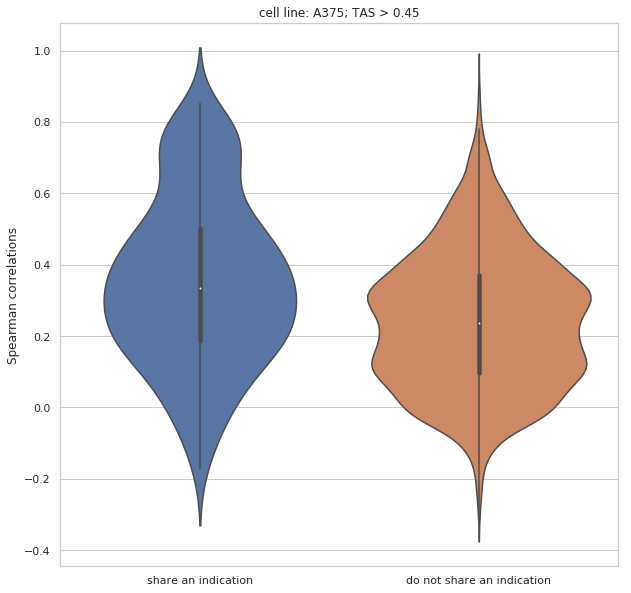

('TAS threshold', 0.45, 'p value:', 5.044922841040301e-151)


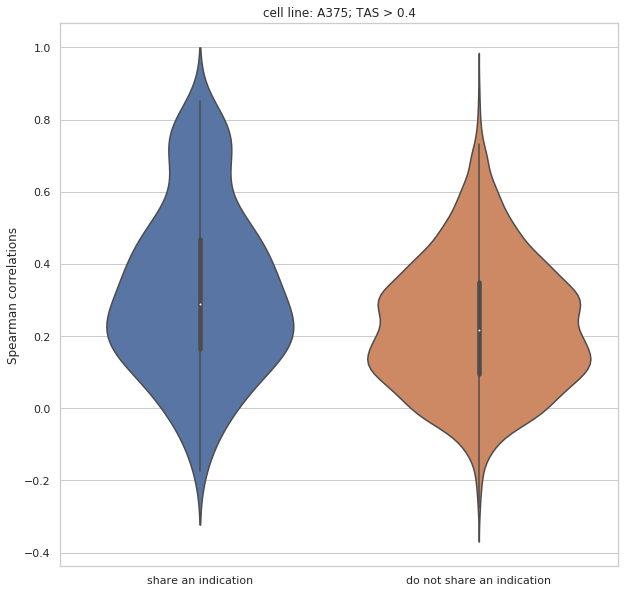

('TAS threshold', 0.4, 'p value:', 3.860660145130443e-182)


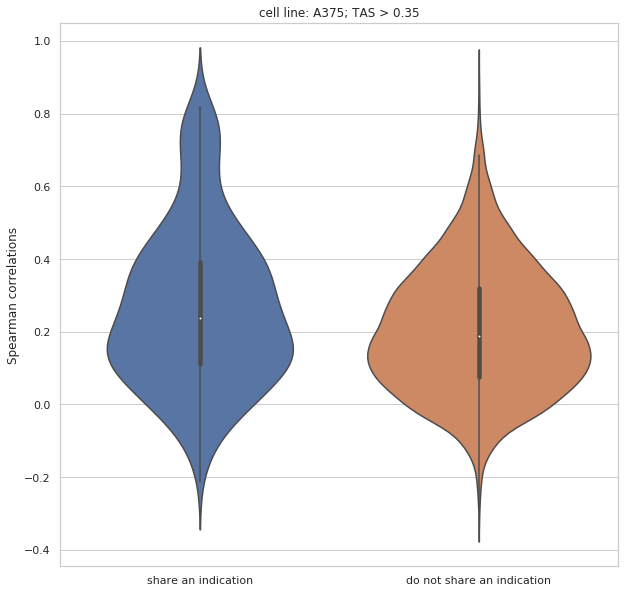

('TAS threshold', 0.35, 'p value:', 7.609462037822735e-282)


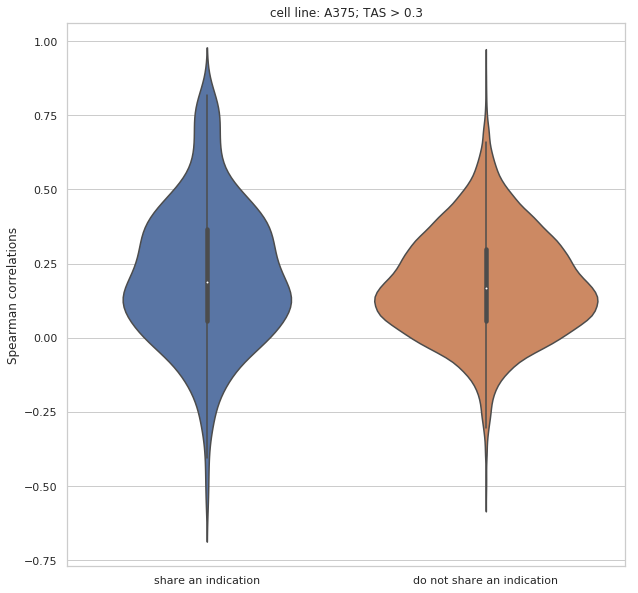

('TAS threshold', 0.3, 'p value:', 0.0)


In [41]:
# create an empty dictionary to store the spearman_correlations for each the tas_threshold
A375_tas_threshold_spearman_corrs = {}

# create an empty dictionary to store the results from the rank-sum test for each tas threshold
tas_threshold_rank_sum = {
    'TAS threshold': [],
    'rank sum p-value': []
}

# create a list of all TAS thresholds you want to be compared
tas_thresholds = [0.75, 0.7, 0.65, 0.6, 0.55, 0.5, 0.45, 0.4, 0.35, 0.3]

# for each TAS threshold,
for tas in tas_thresholds:
    ### 1. select the samples for that cell line above that TAS threshold
    samples2compare = select_samples('A375', tas)
    ###
    
    ### 2. map these samples to their indications
    drug2indications = drug_to_indication(samples2compare)
    ###
    
    ### 3. create pairs of drugs to compare
    pairs2compare = generate_pairs(samples2compare, drug2indications)
    ###
    
    ### 4. select the gene signatures of all samples to be compared
    # read the LINCS Level 5 dataset
    file_path = "/home/katie_huang_student_uml_edu/LINCS_dataset/LINCS_dataset.gctx"

    # select only the landmark gene of drug compounds of interest
    gene_sigs = parse(file_path, rid=lm_gene_id, cid=samples2compare.index)
    ###
    
    ### 5. select the gene signatures for each pair
    pairs_sig_info = select_pairs_gene_sigs(gene_sigs, pairs2compare)
    ###
    
    ### 6. compare the pairs of drugs
    spearman_corrs = compare_drugs(pairs_sig_info)
    ###

    ### 7. make a violin plot to summarize the spearman correlations
    # convert the dictionary into a dataframe
    spearman_corrs_df = pd.DataFrame(spearman_corrs)
    
    # add the spearman correlations to running list
    A375_tas_threshold_spearman_corrs[tas] = spearman_corrs_df
    
    # create a new figure for the histograms with specified sizes
    plt.figure(figsize=(10,10))

    # set a grid on the histograms
    sns.set(style='whitegrid')

    # create a histogram of all spearman correlations for pairs of similar drugs
    sns.violinplot(data=spearman_corrs, x='share an indication', y='spearman correlation', inner='box', common_norm=False)

    # Customize the plot
    plt.title('cell line: A375; TAS > ' + str(tas))
    plt.ylabel("Spearman correlations")

    # Show the plot
    plt.show()
    ###
    
    ### 8. perform a Wilcoxon rank-sum test (Mann-Whitney test)
    # group dataframe by whether they share an indication
    grouped = spearman_corrs_df.groupby('share an indication')['spearman correlation']

    # perform a ranked sum test comparing the pairs of drugs that share an indication to pairs that do not
    statistic, p_value = stats.ranksums(grouped.groups['share an indication'], grouped.groups['do not share an indication'])
    print('TAS threshold', tas,'p value:', p_value)
    
    # save the results from the test
    tas_threshold_rank_sum['TAS threshold'].append(tas)
    tas_threshold_rank_sum['rank sum p-value'].append(p_value)
    ###

In [42]:
# list the tas thresholds and their spearman correlations
A375_tas_threshold_spearman_corrs.keys()

[0.75, 0.5, 0.3, 0.4, 0.55, 0.45, 0.6, 0.65, 0.35, 0.7]

In [43]:
# convert tas_threshold_rank_sum dictionary into a dataframe
A375_rank_sums = pd.DataFrame(tas_threshold_rank_sum)
A375_rank_sums

,TAS threshold,rank sum p-value
0,0.75,7.334669e-23
1,0.70,3.359681e-31
2,0.65,1.107946e-48
3,0.60,3.367611e-77
4,0.55,2.797175e-100
5,0.50,1.392774e-116
6,0.45,5.044923e-151
7,0.40,3.860660e-182
8,0.35,7.609462e-282
9,0.30,0.000000e+00


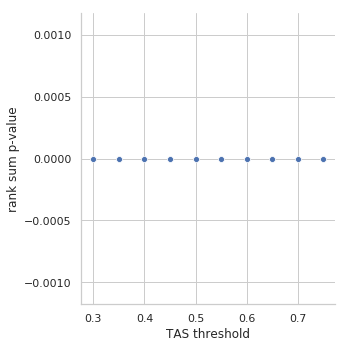

In [44]:
# create a scatter plot comparing the p-values for each tas threshold
sns.relplot(data = A375_rank_sums, 
            x = 'TAS threshold',
            y = 'rank sum p-value'
)

#### *c. PC3 cell line*

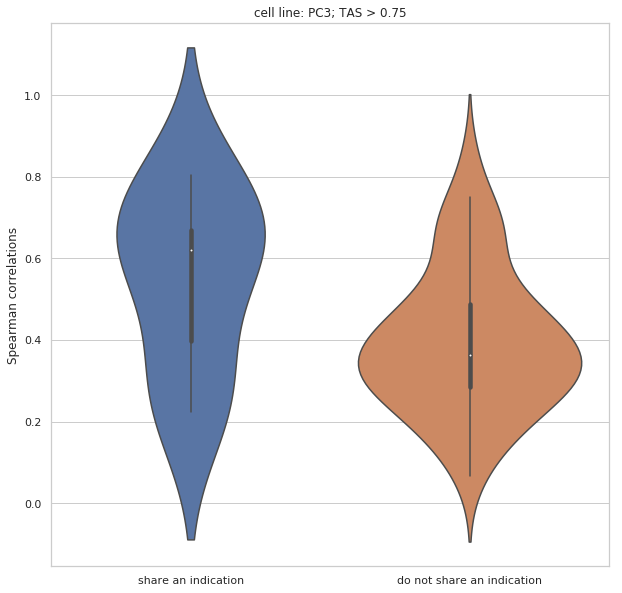

('TAS threshold', 0.75, 'p value:', 7.228793882618055e-05)


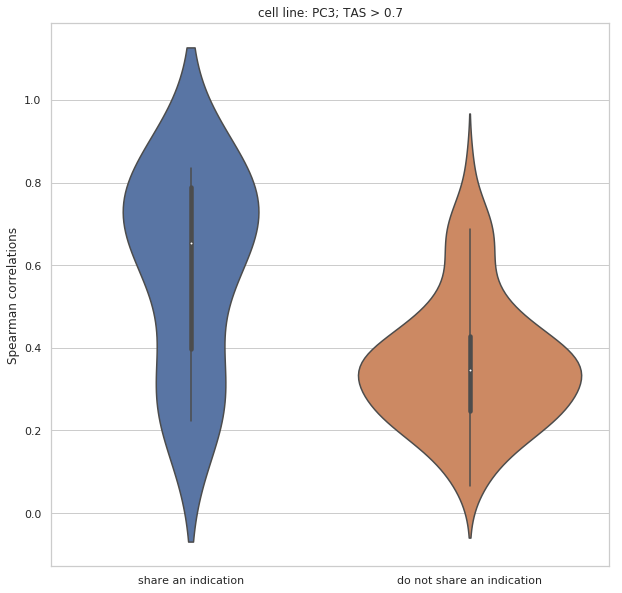

('TAS threshold', 0.7, 'p value:', 1.766860442187839e-07)


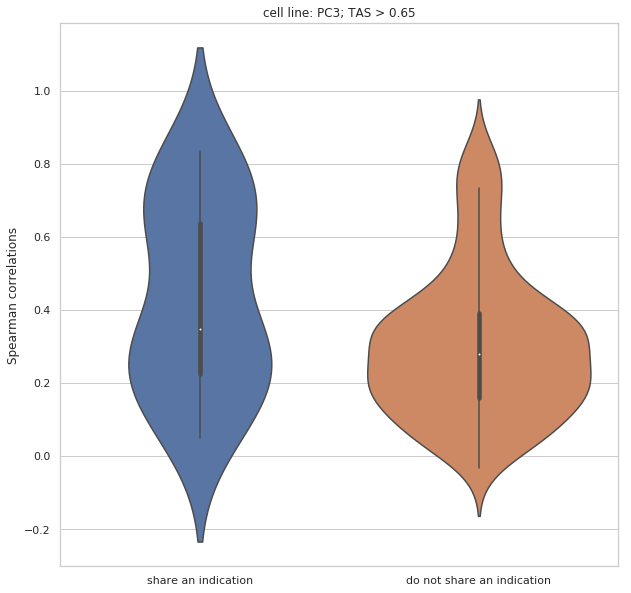

('TAS threshold', 0.65, 'p value:', 2.1439727485884984e-14)


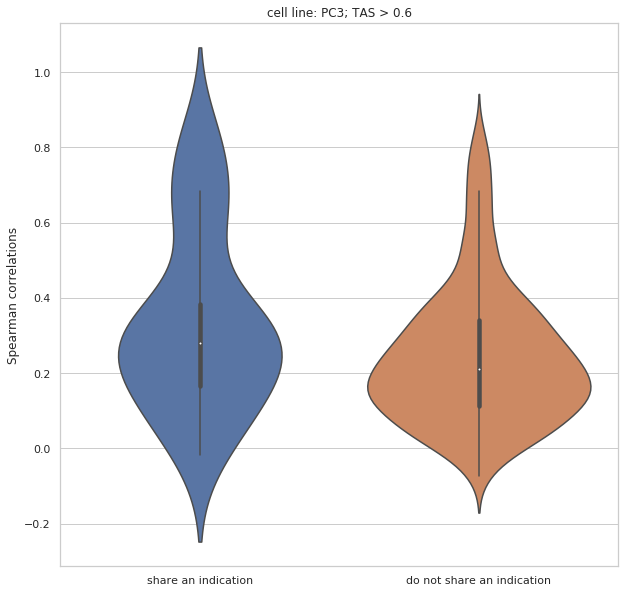

('TAS threshold', 0.6, 'p value:', 6.986899311839959e-25)


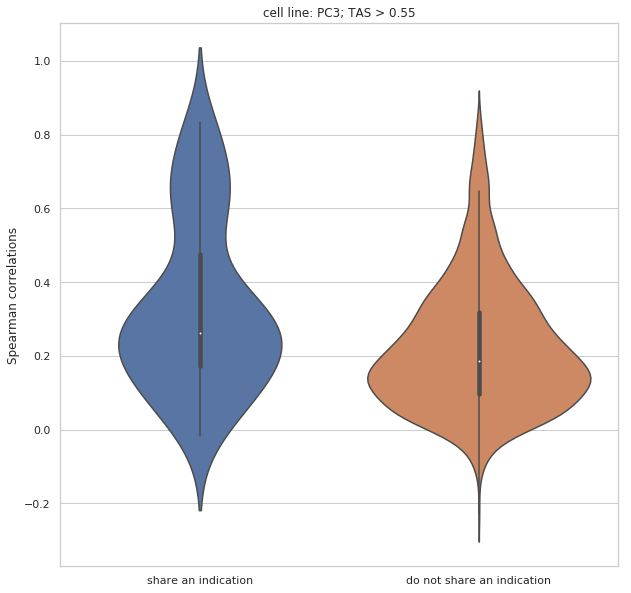

('TAS threshold', 0.55, 'p value:', 5.8790733686999194e-40)


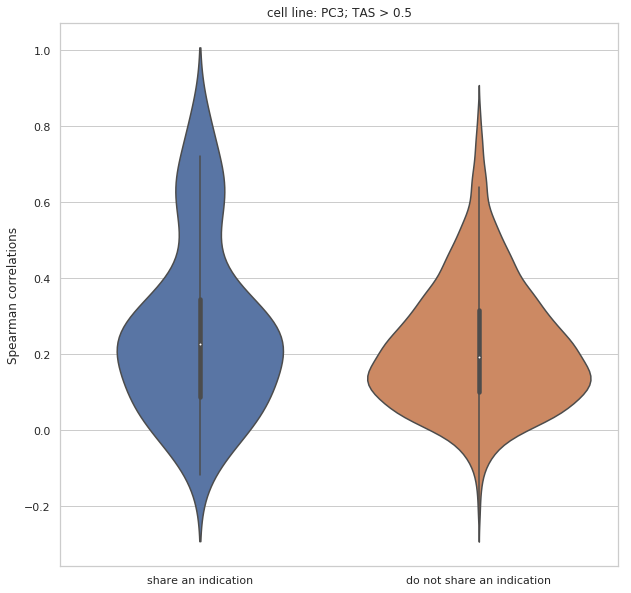

('TAS threshold', 0.5, 'p value:', 7.791667632411332e-75)


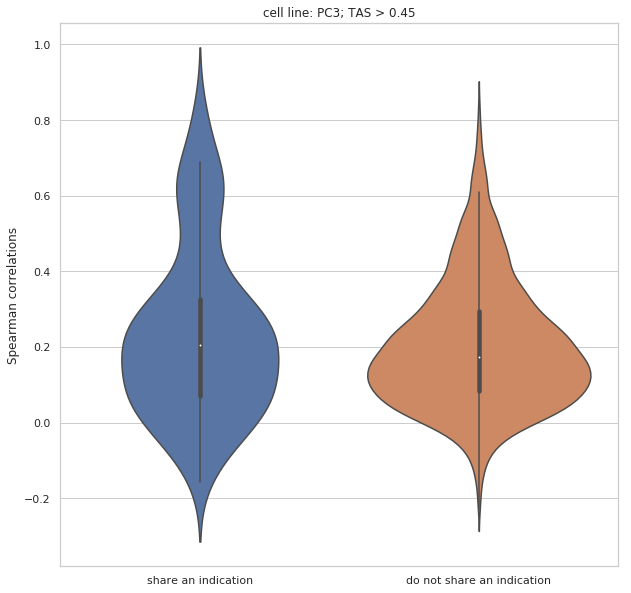

('TAS threshold', 0.45, 'p value:', 1.2234000980919856e-120)


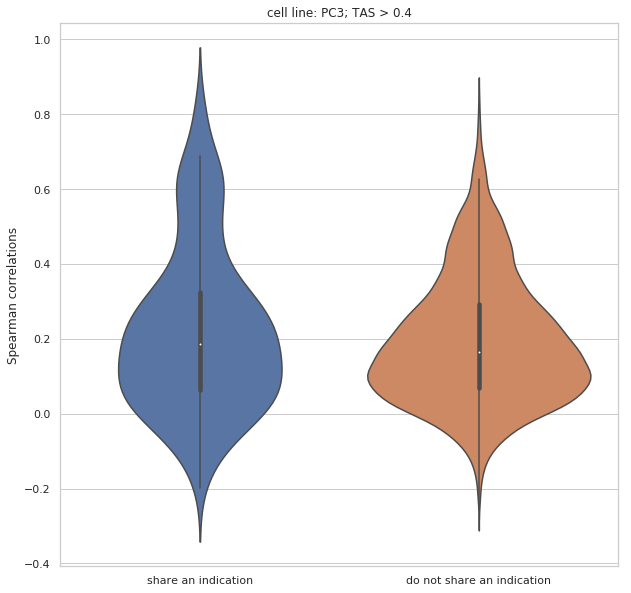

('TAS threshold', 0.4, 'p value:', 9.111998474236902e-166)


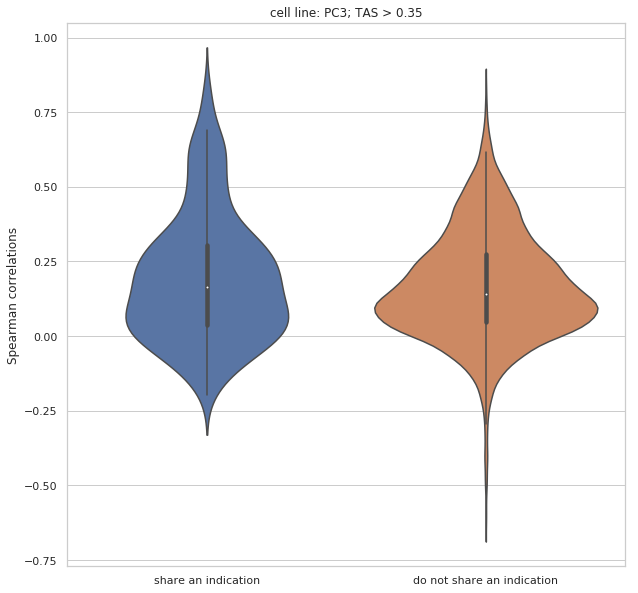

('TAS threshold', 0.35, 'p value:', 6.829929435477233e-225)


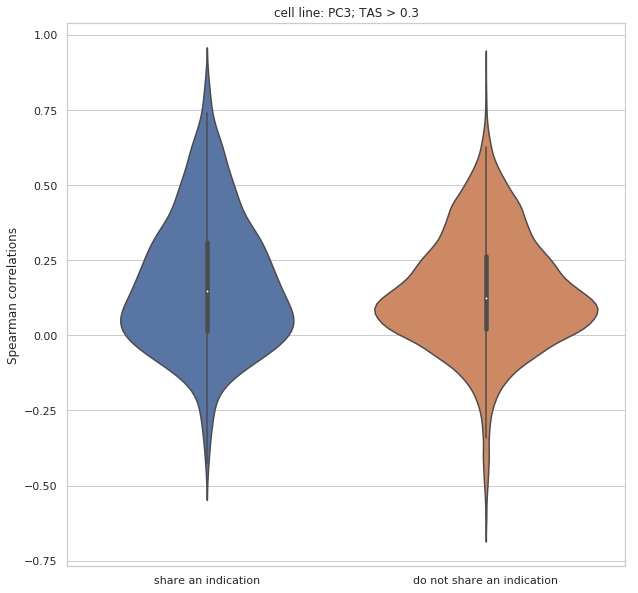

('TAS threshold', 0.3, 'p value:', 0.0)


In [45]:
# create an empty dictionary to store the spearman_correlations for each the tas_threshold
PC3_tas_threshold_spearman_corrs = {}

# create an empty dictionary to store the results from the rank-sum test for each tas threshold
tas_threshold_rank_sum = {
    'TAS threshold': [],
    'rank sum p-value': []
}

# create a list of all TAS thresholds you want to be compared
tas_thresholds = [0.75, 0.7, 0.65, 0.6, 0.55, 0.5, 0.45, 0.4, 0.35, 0.3]

# for each TAS threshold,
for tas in tas_thresholds:
    ### 1. select the samples for that cell line above that TAS threshold
    samples2compare = select_samples('PC3', tas)
    ###
    
    ### 2. map these samples to their indications
    drug2indications = drug_to_indication(samples2compare)
    ###
    
    ### 3. create pairs of drugs to compare
    pairs2compare = generate_pairs(samples2compare, drug2indications)
    ###
    
    ### 4. select the gene signatures of all samples to be compared
    # read the LINCS Level 5 dataset
    file_path = "/home/katie_huang_student_uml_edu/LINCS_dataset/LINCS_dataset.gctx"

    # select only the landmark gene of drug compounds of interest
    gene_sigs = parse(file_path, rid=lm_gene_id, cid=samples2compare.index)
    ###
    
    ### 5. select the gene signatures for each pair
    pairs_sig_info = select_pairs_gene_sigs(gene_sigs, pairs2compare)
    ###
    
    ### 6. compare the pairs of drugs
    spearman_corrs = compare_drugs(pairs_sig_info)
    ###

    ### 7. make a violin plot to summarize the spearman correlations
    # convert the dictionary into a dataframe
    spearman_corrs_df = pd.DataFrame(spearman_corrs)
    
    # add the spearman correlations to running list
    PC3_tas_threshold_spearman_corrs[tas] = spearman_corrs_df
    
    # create a new figure for the histograms with specified sizes
    plt.figure(figsize=(10,10))

    # set a grid on the histograms
    sns.set(style='whitegrid')

    # create a histogram of all spearman correlations for pairs of similar drugs
    sns.violinplot(data=spearman_corrs, x='share an indication', y='spearman correlation', inner='box', common_norm=False)

    # Customize the plot
    plt.title('cell line: PC3; TAS > ' + str(tas))
    plt.ylabel("Spearman correlations")

    # Show the plot
    plt.show()
    ###
    
    ### 8. perform a Wilcoxon rank-sum test (Mann-Whitney test)
    # group dataframe by whether they share an indication
    grouped = spearman_corrs_df.groupby('share an indication')['spearman correlation']

    # perform a ranked sum test comparing the pairs of drugs that share an indication to pairs that do not
    statistic, p_value = stats.ranksums(grouped.groups['share an indication'], grouped.groups['do not share an indication'])
    print('TAS threshold', tas,'p value:', p_value)
    
    # save the results from the test
    tas_threshold_rank_sum['TAS threshold'].append(tas)
    tas_threshold_rank_sum['rank sum p-value'].append(p_value)
    ###

In [46]:
PC3_tas_threshold_spearman_corrs.keys()

[0.75, 0.5, 0.3, 0.4, 0.55, 0.45, 0.6, 0.65, 0.35, 0.7]

In [49]:
PC3_tas_threshold_spearman_corrs[0.6]

,p value,share an indication,spearman correlation
0,1.512737e-12,share an indication,0.223596
1,6.022744e-01,share an indication,-0.016684
2,1.037149e-112,share an indication,0.637607
3,1.132134e-25,share an indication,0.326151
4,3.292940e-26,share an indication,0.329567
5,3.196490e-19,share an indication,0.281125
6,3.406393e-10,share an indication,0.199025
7,6.118418e-107,share an indication,0.624650
8,1.974852e-35,share an indication,0.382509
9,1.097586e-02,share an indication,0.081300


In [47]:
# convert tas_threshold_rank_sum dictionary into a dataframe
PC3_rank_sums = pd.DataFrame(tas_threshold_rank_sum)
PC3_rank_sums

,TAS threshold,rank sum p-value
0,0.75,7.228794e-05
1,0.70,1.766860e-07
2,0.65,2.143973e-14
3,0.60,6.986899e-25
4,0.55,5.879073e-40
5,0.50,7.791668e-75
6,0.45,1.223400e-120
7,0.40,9.111998e-166
8,0.35,6.829929e-225
9,0.30,0.000000e+00


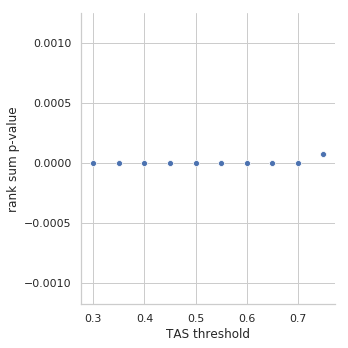

In [48]:
# create a scatter plot comparing the p-values for each tas threshold
sns.relplot(data = PC3_rank_sums, 
            x = 'TAS threshold',
            y = 'rank sum p-value'
)

Lowering the TAS threshold decreases the rank sum p-value despite the violin plots indicating otherwise.

Instead of using the rank sum test, I will try using the ROC curves and AUC values to compare.